# Yield Curve Module 1
***NSS from ECB Parameters -- AAA Government Curve***

---

**The NSS Nelson-Siegel-Svensson is a parametric yield curve model. It fits a smooth curve on observed market yields across maturities.**

This notebook pulls live Nelson-Siegel-Svensson parameters from the
ECB Statistical Data Warehouse (ECB SDW) and reconstructs the euro area government yield curve.

The ECB publishes two NSS curves daily:

- **AAA-rated issuers** (`G_N_A`) -- Germany, Netherlands, Finland, Luxembourg.
  The primary reference curve used in monetary policy analysis and this notebook.
  Strips out peripheral credit risk, giving a cleaner picture of the euro area
  term structure.
- **All issuers, all ratings** (`G_N_C`) -- full euro area sovereign universe
  including Italy, Spain, Portugal. Embeds peripheral credit spreads.

**What we are building:**
- The NSS formula
- Live ECB parameter fetch via our ECBClient
- Zero rate curve from 1 month to 30 years
- Historical analysis of curve shape and parameter evolution

None:
* Hierarchy: OIS (risk-free anchor) < AAA NSS (safe sovereign benchmark) < all-issuer NSS (credit-stressed sovereign curve)
* Usage: NSS curves are for benchmarking, decomposition, and validation, not for regulatory discounting.The later uses quasi-risk free OIS curves.

In [ ]:
from quant_risk.setup import base
np, pd, plt = base()

from quant_risk.data.ecb import ECBClient

imports ok


## 1. The NSS Formula

The Nelson-Siegel-Svensson model describes the zero rate at maturity $T$ as:

$$r(T) = \beta_0 + \beta_1 \cdot \frac{1 - e^{-T/\tau_1}}{T/\tau_1} + \beta_2 \cdot \left(\frac{1 - e^{-T/\tau_1}}{T/\tau_1} - e^{-T/\tau_1}\right) + \beta_3 \cdot \left(\frac{1 - e^{-T/\tau_2}}{T/\tau_2} - e^{-T/\tau_2}\right)$$

Where:
- $\beta_0$ -- long run level (asymptote as $T \to \infty$)
- $\beta_1$ -- slope (spread between short rate and long run level)
- $\beta_2$ -- first hump, controlled by $\tau_1$
- $\beta_3$ -- second hump, controlled by $\tau_2$ (Svensson extension)

In [56]:
def nss_zero_rate(T, beta0, beta1, beta2, beta3, tau1, tau2):
    """
    Nelson-Siegel-Svensson zero rate at maturity T (in years).

    Parameters
    ----------
    T : float or np.ndarray
        Maturity in years. Must be > 0.
    beta0, beta1, beta2, beta3 : float
        Level, slope, and curvature parameters.
    tau1, tau2 : float
        Decay parameters controlling hump locations.

    Returns
    -------
    float or np.ndarray
        Zero rate in decimal.
    """
    T = np.asarray(T, dtype=float)

    # avoid division by zero at T=0
    T = np.where(T < 1e-6, 1e-6, T)

    f1 = (1 - np.exp(-T / tau1)) / (T / tau1)
    f2 = f1 - np.exp(-T / tau1)
    f3 = (1 - np.exp(-T / tau2)) / (T / tau2) - np.exp(-T / tau2)

    return (beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3) / 100

# quick sanity check
print(f"{nss_zero_rate(10, 1.178, 0.721, 1.991, 7.699, 0.808, 14.616):.2%}")

3.09%


In [57]:
client = ECBClient()
params = client.get_nss_parameters(last_n=1) # 1-row df
print(params)

# extract today's parameters as a dict
p = params.iloc[-1] # a dataseries
print(f"\nDate: {params.index[-1]}")

              beta0    beta1    beta2    beta3     tau1      tau2
2026-05-28 1.312516 0.710695 1.700558 7.129620 0.952992 15.868939

Date: 2026-05-28


## 2. Reconstructing the Full Curve

Curves reconstructed using last ECB parameters, for the full maturity spectrum (1m to 30y):

1. Zero rates $r(T)$
2. Discount factors $P(0,T)$ (=zero coupon bond price)
3. Instantaneous forward rate $f(0,T)$: rate for infinitesimal period at $T$ (options, HJM, term structure models)
4. Discrete forward rate $f(t, t+1)$: rate for the period from $t$ to $t+1$ (bond pricing, swap legs)

### Continuous vs Discrete Forward Rates

Both forward rates answer the same question: *what rate does the market imply for a future lending period?*. But they hold different compounding assumptions.

#### **Discrete forward rate** 

Is the rate between maturities $t$ and $t+1$ that
chains exactly with the zero rates:

$$(1 + r_{t+1})^{t+1} = (1 + r_t)^t \cdot (1 + f_{t \to t+1})$$

Solving for the forward:

$$f_{t \to t+1} = \frac{(1 + r_{t+1})^{t+1}}{(1 + r_t)^t} - 1$$

By construction, plugging this back in reconciles exactly with the next
zero rate, without any numerical approximation error. Used in where discrete compounding matches contractual cash flow conventions: 
* bond pricing
* swap leg projections

#### **Continuous forward rate** 

It is the instantaneous rate at maturity $T$:

$$f(0,T) = -\frac{d}{dT} \ln P(0,T)$$

Note: $ln$ appears because in continuous time the discount factor is $P(0,T) = e^{-\int_0^T f(0,u)\,du}$

Computed numerically below using *finite differences* on the discount curve. Used where continuous compounding is the natural convention:
* options pricing
* HJM framework
* term structure models 
* XVA



In [58]:
# finite difference approximation of a derivative using nearby points on a grid

# maturity grid from 1 month to 30 years
maturities = np.linspace(1/12, 30, 360)

# zero rates using today's parameters
zero_rates = nss_zero_rate(
    maturities,
    beta0 = p.beta0,
    beta1 = p.beta1,
    beta2 = p.beta2,
    beta3 = p.beta3,
    tau1  = p.tau1,
    tau2  = p.tau2,
)

# discount factors: P(0,T) = exp(-r(T) * T / 100)
discount_factors = np.exp(-zero_rates * maturities)

# continuous forward rates: f(0,T) = -d/dT ln P(0,T)
# numerical approximation using finite differences
dT = maturities[1] - maturities[0]
fwd_continuous = (-np.diff(np.log(discount_factors)) / dT) 
# align array length with maturities by repeating last observed value
fwd_continuous = np.append(fwd_continuous, fwd_continuous[-1]) 

# discrete forward rates: f(t, t+1) = (1+r_{t+1})^{t+1} / (1+r_t)^t - 1
# rates divided by 100 for computation, result multiplied back
r = zero_rates 
growth = (1 + r) ** maturities
fwd_discrete_step = np.diff(growth) / growth[:-1]
# align array length with maturities by repeating last observed value
fwd_discrete_step = np.append(fwd_discrete_step, fwd_discrete_step[-1])

# annualise: each step is dT years, so compound up to 1 year
fwd_discrete = ((1 + fwd_discrete_step) ** (1 / dT) - 1) 

# collect into a DataFrame
curve = pd.DataFrame({
    "maturity"        : maturities,
    "zero_rate"       : zero_rates,
    "discount_factor" : discount_factors,
    "fwd_continuous"  : fwd_continuous,
    "fwd_discrete"    : fwd_discrete,
})

curve.head(10).style\
    .format({
        'maturity': "{:.2f}", 
        'zero_rate': "{:.2%}",
        'discount_factor': "{:.6f}",
        'fwd_continuous': "{:.2%}",
        'fwd_discrete': "{:.2%}"
    })\
    .set_caption(f"EUR Government Key Rates")

,maturity,zero_rate,discount_factor,fwd_continuous,fwd_discrete
0,0.08,2.08%,0.998267,2.19%,2.19%
1,0.17,2.13%,0.996449,2.27%,2.27%
2,0.25,2.18%,0.994563,2.35%,2.35%
3,0.33,2.22%,0.992619,2.41%,2.41%
4,0.42,2.26%,0.990630,2.46%,2.46%
5,0.50,2.29%,0.988603,2.50%,2.50%
6,0.58,2.32%,0.986548,2.53%,2.53%
7,0.67,2.35%,0.984470,2.56%,2.56%
8,0.75,2.37%,0.982376,2.58%,2.58%
9,0.83,2.39%,0.980269,2.59%,2.59%


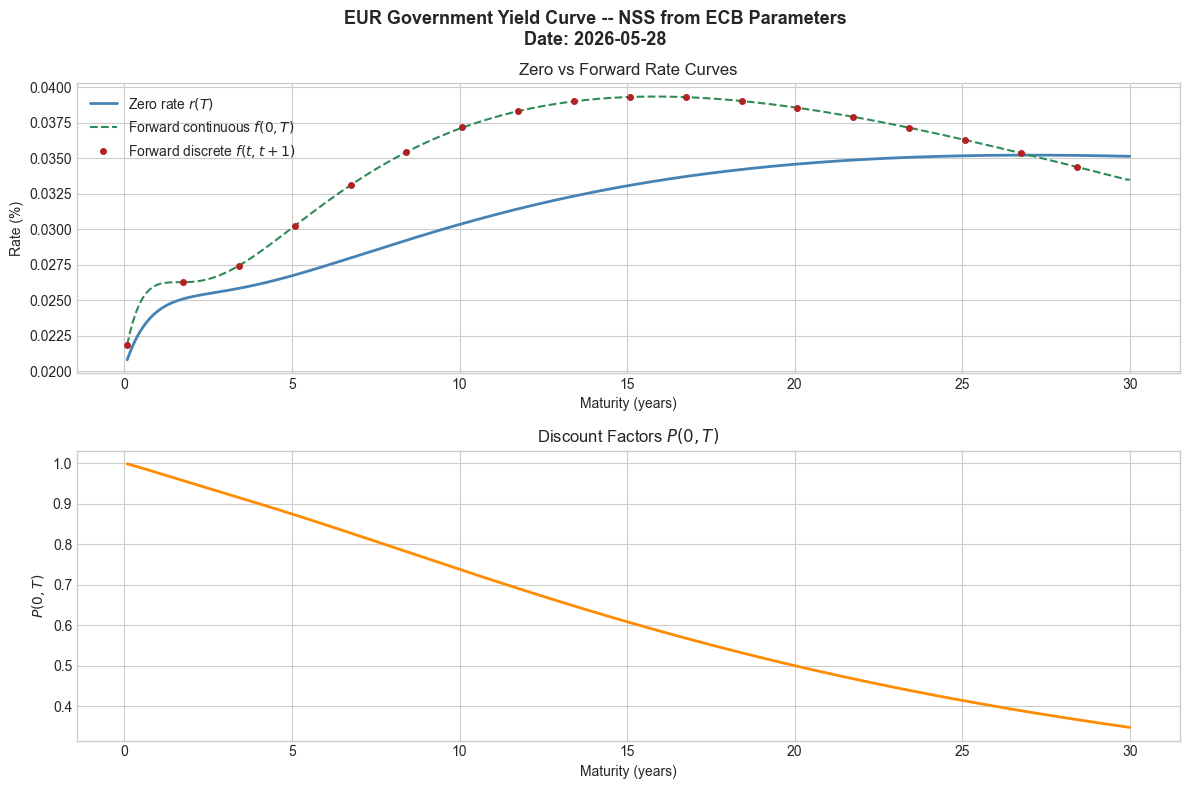

In [59]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(12, 8))

# zero and both forward rates together
ax1.plot(
    curve.maturity, curve.zero_rate,
    color="steelblue", linewidth=2, label="Zero rate $r(T)$"
)
ax1.plot(
    curve.maturity, curve.fwd_continuous,
    color="seagreen", linewidth=1.5,
    linestyle="--", label="Forward continuous $f(0,T)$"
)
ax1.plot(
    curve.maturity, curve.fwd_discrete,
    color="firebrick", linewidth=0.8,
    marker="o", markevery=20, markersize=4,
    linestyle="none",
    label="Forward discrete $f(t,t+1)$"
)
ax1.set_title("Zero vs Forward Rate Curves")
ax1.set_ylabel("Rate (%)")
ax1.set_xlabel("Maturity (years)")
ax1.legend()

# discount factors
ax2.plot(
    curve.maturity, curve.discount_factor,
    color="darkorange", linewidth=2
)
ax2.set_title("Discount Factors $P(0,T)$")
ax2.set_ylabel("$P(0,T)$")
ax2.set_xlabel("Maturity (years)")

fig.suptitle(
    f"EUR Government Yield Curve -- NSS from ECB Parameters\n"
    f"Date: {params.index[-1]}",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Continuous vs Discrete Forward Rates -- Comparison

Both measures are plotted together above. At this grid resolution (monthly steps, $dT \approx 0.083$ years)
the two are visually indistinguishable.

The discrete forward rate converges to the continuous one as the interval shrinks:

$$\lim_{\Delta t \to 0} \frac{(1 + r_{t+\Delta t})^{t + \Delta t}}{(1 + r_t)^t} - 1 = f(0,T) \cdot \Delta t$$


In [16]:
diff = curve.fwd_discrete - curve.fwd_continuous
print(f"Max difference:  {diff.abs().max():.6f}%")
print(f"Mean difference: {diff.abs().mean():.6f}%")
print(f"At 1Y:  discrete={curve.fwd_discrete[12]:.4f}%  continuous={curve.fwd_continuous[12]:.4f}%")
print(f"At 10Y: discrete={curve.fwd_discrete[120]:.4f}%  continuous={curve.fwd_continuous[120]:.4f}%")

Max difference:  0.002698%
Mean difference: 0.001046%
At 1Y:  discrete=2.5776%  continuous=2.5775%
At 10Y: discrete=3.8284%  continuous=3.8258%


## 3. Historical Analysis -- Curve Evolution

Pulling 2 years of NSS parameters to show how the EUR government curve
evolved through the ECB rate hiking cycle (2022-2023), subsequent
cutting cycle (2024-2025) and Iranian war.

Key parameters to watch:
- $\beta_0$ -- long run level: did the market reprice the neutral rate?
- $\beta_1$ -- slope: when did the curve invert and when did it normalise?
- $\beta_0 + \beta_1$ -- instantaneous short rate implied by the model

In [60]:
# fetch 2 years of daily NSS parameters
params_hist = client.get_nss_parameters(last_n=520)
params_hist.index = pd.to_datetime(params_hist.index)
params_hist = params_hist.sort_index()

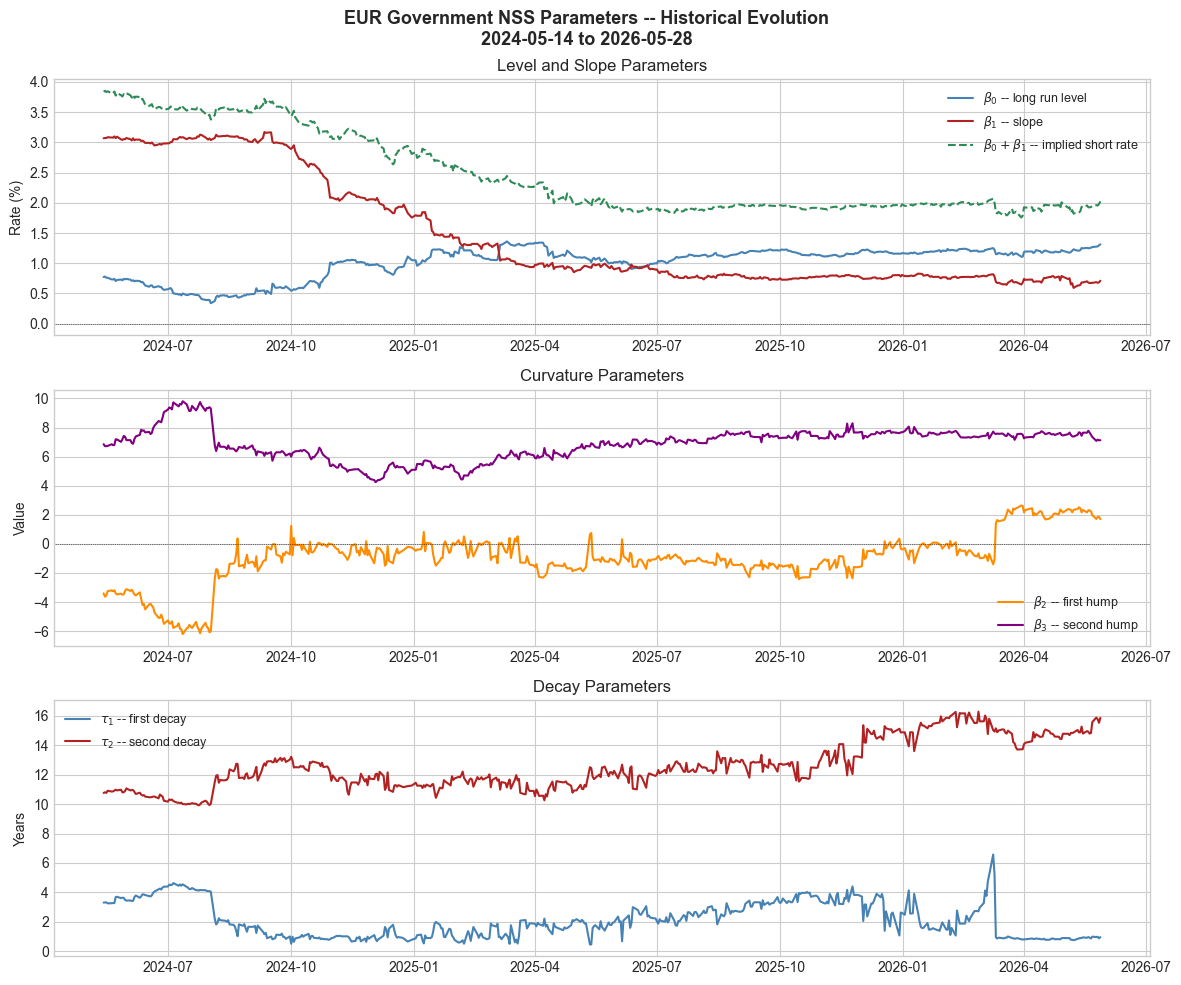

In [61]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# beta0 and beta1 -- the most economically meaningful
ax1.plot(params_hist.index, params_hist.beta0,
         color="steelblue", linewidth=1.5, label="$\\beta_0$ -- long run level")
ax1.plot(params_hist.index, params_hist.beta1,
         color="firebrick", linewidth=1.5, label="$\\beta_1$ -- slope")
ax1.plot(params_hist.index, params_hist.beta0 + params_hist.beta1,
         color="seagreen", linewidth=1.5, linestyle="--",
             label="$\\beta_0 + \\beta_1$ -- implied short rate")
ax1.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax1.set_title("Level and Slope Parameters")
ax1.set_ylabel("Rate (%)")
ax1.legend(fontsize=9)

# beta2 and beta3 -- curvature
ax2.plot(params_hist.index, params_hist.beta2,
             color="darkorange", linewidth=1.5, label="$\\beta_2$ -- first hump")
ax2.plot(params_hist.index, params_hist.beta3,
             color="purple", linewidth=1.5, label="$\\beta_3$ -- second hump")
ax2.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax2.set_title("Curvature Parameters")
ax2.set_ylabel("Value")
ax2.legend(fontsize=9)

# tau1 and tau2 -- decay speeds
ax3.plot(params_hist.index, params_hist.tau1,
             color="steelblue", linewidth=1.5, label="$\\tau_1$ -- first decay")
ax3.plot(params_hist.index, params_hist.tau2,
             color="firebrick", linewidth=1.5, label="$\\tau_2$ -- second decay")
ax3.set_title("Decay Parameters")
ax3.set_ylabel("Years")
ax3.legend(fontsize=9)

fig.suptitle(
    "EUR Government NSS Parameters -- Historical Evolution\n"
    f"{params_hist.index[0].date()} to {params_hist.index[-1].date()}",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

### Level and slope

- $\beta_1$ collapsed from 3.1% (Apr 2024) to 0.7% (mid-2025) and has stabilised there. This is the ECB cutting cycle made visible.
- Start of sample: implied short rate $\beta_0 + \beta_1 \approx 4\%$, far above the long-run level $\beta_0 \approx 0.85\%$. Deeply inverted, reflecting peak policy tightening at 4% deposit rate, not a recession signal.
- By early 2025: curve normalised to $\beta_0 + \beta_1 \approx 2\%$, with $\beta_0 \approx 1.2\%$, implying a terminal rate consistent with ECB staff estimates of $r^* = 1.0$-$1.5\%$.
- $\beta_1$ flat at 0.7% from mid-2025 onward signals markets consider the cutting cycle complete.

### Curvature

- $\beta_2$ (first hump, belly 2-5Y): moved from deeply negative ($-6$, mid-2024) to slightly positive by Apr 2026. Negative values suppressed the belly under inversion; the drift positive reflects cut expectations fading.
- **Iran shock (Feb 2026):** ECB held rates at 2%, Lagarde warned of "material impact on near-term inflation." Markets repriced from cuts to possible hikes. The recent jump to $+2$ is directly linked to markets repricing ECB cuts to holds or hikes post-Iran shock. The belly now carries an inflation risk premium.
- $\beta_3$ (second hump, long end): remarkably stable at 6-8 throughout. Structural duration demand from European pension funds and insurers keeps the long end well-behaved regardless of short-term policy moves.


### Decay parameters

- $\tau_2$: steady drift from 10-11Y to 15-16Y. The second hump is being pushed further out as QT reduces ECB long-dated holdings and the long-end term premium reprices upward.
- $\tau_1$ spike in early 2026: the most visually dramatic feature. Likely a fitting artefact, not a genuine market signal. When $\beta_1$ is small the first hump has little economic significance and the optimiser struggles to pin $\tau_1$ precisely. This is a known NSS limitation in low-slope environments.
- The Iran shock abruptly moved the very short end of the EUR curve, consistent with the fitting stress that destabilises $\tau_1$. ECB consumer inflation expectations were revised up by 2.5pp in a single month after the conflict began (Mar 2026 ECB survey), amplifying short-end volatility. Fistr hump is now steadily parked at 1 year.

### IRRBB implications

- Transition from inverted to normal slope increases EVE sensitivity under EBA parallel shock scenarios ($\pm 200$ bps): long-end discount factors are more sensitive starting from lower rates.
- Banks positioned for prolonged inversion through 2024 faced mark-to-market losses as the curve normalised.
- The Iran shock introduces a distinct tail scenario: a stagflationary curve shape where 1-5Y rates rise on renewed inflation fears while 10Y+ stays anchored by weak growth expectations. This is not well captured by standard parallel shift assumptions.
- IRRBB models should be stress-tested against a non-parallel steepener where 1-5Y rates rise 75-100 bps while 10Y+ moves less than 25 bps.

## 7. Parameter Sensitivity Analysis

Single-parameter shifts around today's ECB calibration, all others held fixed.
Shift sizes are ±1σ and ±2σ computed from the 2024-2026 daily parameter series.

For $\beta$ parameters shifts are applied symmetrically. For $\tau_1$ and $\tau_2$
negative shifts are floored at a minimum value of 0.1 years as both decay parameters
are strictly positive by construction.

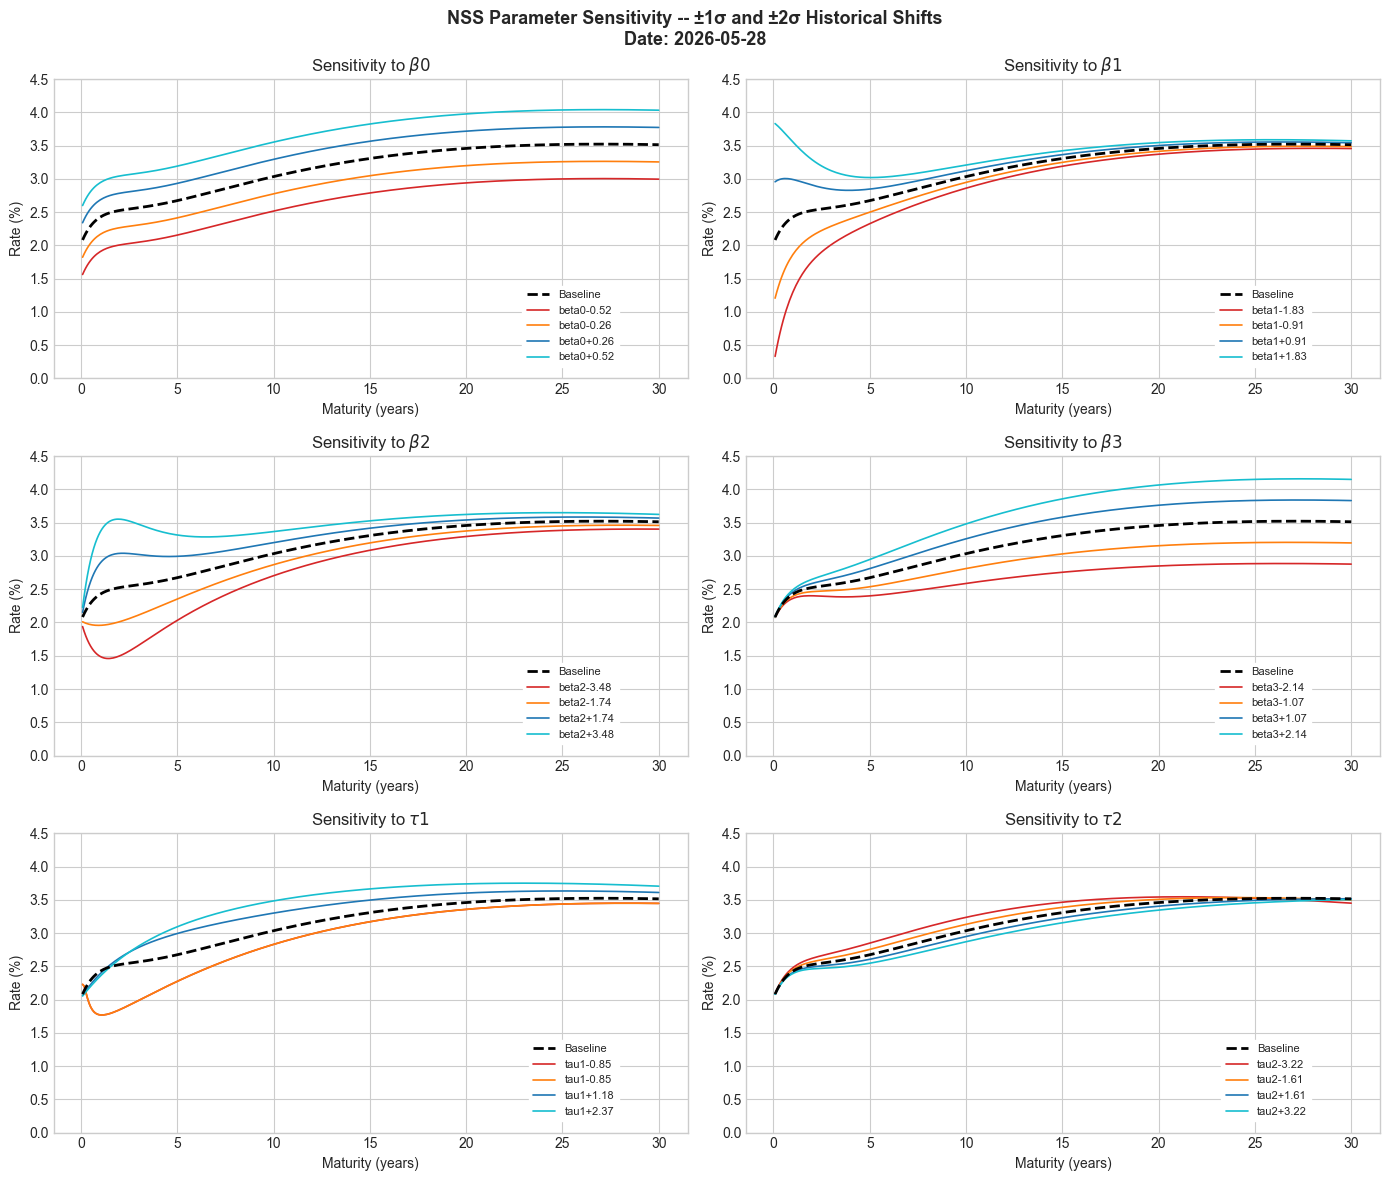

              beta0    beta1    beta2    beta3     tau1      tau2
2026-05-28 1.312516 0.710695 1.700558 7.129620 0.952992 15.868939


In [64]:
# today's parameters as baseline
base = dict(
    beta0 = p.beta0,
    beta1 = p.beta1,
    beta2 = p.beta2,
    beta3 = p.beta3,
    tau1  = p.tau1,
    tau2  = p.tau2,
)

# maturity grid
T = np.linspace(1/12, 30, 360)

# baseline curve
baseline = nss_zero_rate(T, **base)*100

# shift sizes: +-1 and +-2 historical standard deviations
# tau parameters floored at 0.1 years -- strictly positive by construction
stds = params_hist.std()

def safe_shifts(param, today_val):
    raw = [-2*stds[param], -1*stds[param], 1*stds[param], 2*stds[param]]
    if param in ["tau1", "tau2"]:
        return [max(s, 0.1 - today_val) for s in raw]
    return raw

shifts = {
    param: safe_shifts(param, base[param])
    for param in base.keys()
}

colors = ["#d62728", "#ff7f0e","#1f77b4", "#17becf"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (param, shift_vals) in enumerate(shifts.items()):
    ax = axes[idx]

    # baseline
    ax.plot(T, baseline, color="black", linewidth=2,
            linestyle="--", label="Baseline", zorder=5)

    for i, s in enumerate([v for v in shift_vals]):
        shocked = base.copy()
        shocked[param] += s
        ax.plot(T, nss_zero_rate(T, **shocked)*100,
                color=colors[i], linewidth=1.2,
                label=f"{param}{s:+.2f}")

    ax.set_title(f"Sensitivity to $\\{param}$" if param.startswith("beta")
                 else f"Sensitivity to $\\{param}$")
    ax.set_ylabel("Rate (%)")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylim(0, 4.5)
    ax.legend(fontsize=8, loc="lower right", facecolor="white", 
              frameon=True, framealpha=1, edgecolor="white", 
              bbox_to_anchor=(0.9, 0.02)
              )

fig.suptitle(
    "NSS Parameter Sensitivity -- ±1σ and ±2σ Historical Shifts\n"
    f"Date: {params.index[-1]}",
    fontsize=13, fontweight="bold"
)

plt.tight_layout()
plt.show()

print(params)

Notice that as $\tau_1$ and $\tau_2$ define the location of the humps $\beta_2$ and $\beta_3$, which is clear by the sensitivity plots shown above.

---

### ILLUSTRATIVE RISK APPLICATIONS 
Below we show key metrics and decompositions (duration, DV01, and key rate sensitivities). Regulatory frameworks require OIS-based discounting with explicit spread construction. Here, we use AAA NSS government curves as a reasonable proxy at the sovereign level, as they embed liquidity and residual risk premia. However, this approach would not be appropriate for regulatory purposes, since NSS curves are not a discounting framework but a fitted yield curve representation.

## A. Key Rate Table

In European Banking Authority IRRBB frameworks, banks commonly decompose interest rate risk into sensitivities across <span style="color:pink">standard maturity pillars</span>, such as:

* 1M, 3M, 6M
* 1Y, 2Y, 5Y
* 10Y, 15Y, 20Y, 30Y (institution-dependent)

These pillar sensitivities are used to analyse:

* EVE sensitivity (Economic Value of Equity)
* NII sensitivity (Net Interest Income)
* non-parallel curve risk (steepener / flattener effects)

This decomposition is commonly referred to as:

* key rate duration
* bucketed DV01 / PV01
* pillar sensitivity analysis


## B. DV01 and Duration

DV01, the **Dollar Value of a Basis Point**, measures the **price sensitivity of a position to a 1 basis point (0.01%) move in interest rates**. It is a standard risk metric on fixed income desks and a building block for IRRBB EVE calculations.

* Note 1: We use $r(T)$ as the NSS zero rate curve to price zero-coupon bonds and discount cash flows of equivalent risk. For regulatory fillings, the discount curve is built from OIS curve plus risk spread.
* Note 2: DV01 is defined as the change in price for a $1 bp$ parallel shift in $r(t)$. It can be computed at key-rate level (IRRBB pillar shocks). The sum of key-rate DV01s gives total DV01. Modified duration is the total is DV01 normalized by price.

Both **total DV01** and modified duration therefore represent sensitivities to a parallel shift in the discount curve, and equivalently to a 1 bp move in yields under a flat-curve interpretation.

In this notebook, rather than relying on the textbook expression $dP/dy$, we work directly with curve-based sensitivities $dP/dr(t)$, which generalize yield-based intuition to a full term structure setting.




**$DV01$ and $D_\text{mod}$ derivation for a zero coupon bond**

The price of a zero coupon bond with notional $N$ and maturity $T$ is:

$$P = N \cdot P(0,T) = N \cdot e^{-r(T) \cdot T}$$

Taking the derivative with respect to the zero rate $r$:

$$\frac{dP}{dr} = -T \cdot N \cdot P(0,T)$$

DV01 is the price change for a 1 basis point move in $r$: $\Delta r = 0.01\% = 0.0001$. It usually represented as a positive number, so in the definition we add a negative sign, that cancels out the negative derivative result:

$$DV01 = -\frac{dPrice}{dr} \cdot \Delta r  = \frac{T \cdot N \cdot P(0,T)}{10{,}000}$$

For $N = 1{,}000{,}000$:

$$DV01 = T \cdot P(0,T) \cdot 100$$

**Modified Duration**

Modified duration normalises DV01 by the dirty bond price, giving the percentage
price change per unit move in rates:

$$D_\text{mod} = -\frac{1}{P_{bond}} \cdot \frac{dP_{bond}}{dr}$$

The relationship between DV01 and modified
duration is:

$$DV01 = D_\text{mod} \cdot P_{bond} \cdot 0.0001$$

For a coupon bond, modified duration is the present-value weighted average
maturity of all cash flows:

$$D_\text{mod} = \frac{\sum_i T_i \cdot C_i \cdot P(0, T_i)}{P_{bond}}$$

$DV01$ is the more operationally useful metric as it is additive across tenors and can be bucketed by maturity; $D_\text{mod}$ is a scalar normalised by price (a elasticity) and is useful for comparing rate sensitivity across instruments of different sizes.

In [55]:
# standard pillar maturities in years
pillars = {
    "3M":  3/12,
    "6M":  6/12,
    "1Y":  1.0,
    "2Y":  2.0,
    "3Y":  3.0,
    "5Y":  5.0,
    "7Y":  7.0,
    "10Y": 10.0,
    "15Y": 15.0,
    "20Y": 20.0,
    "30Y": 30.0,
}

# compute zero rates and discount factors at each pillar
records = []
for label, T in pillars.items():
    r = nss_zero_rate(
        T,
        beta0 = p.beta0,
        beta1 = p.beta1,
        beta2 = p.beta2,
        beta3 = p.beta3,
        tau1  = p.tau1,
        tau2  = p.tau2,
    )
    df = np.exp(-r * T)
    records.append({
        "maturity"         : label,
        "years"            : T,
        "zero_rate_%"      : round(r, 4),
        "discount_factor"  : round(df, 6),
        "dv01_per_1M" : round(T * df*100, 2),
    })

key_rates = pd.DataFrame(records).set_index("maturity")

key_rates.style\
    .format({
        "years"           : "{:.2f}",
        "zero_rate_%"     : "{:.2%}",
        "discount_factor" : "{:.6f}",
        "mod_duration"    : "{:.2f}",
        "dv01_per_1M"     : "{:,.2f}",
    })\
    .set_caption(f"EUR Government Key Rates -- {params.index[-1]}")\
    .background_gradient(subset=["dv01_per_1M"], cmap="Blues")

DV01 per 1M: 5350.29
Modified Duration: 5.35


,years,zero_rate_%,discount_factor,dv01_per_1M
maturity,,,,
3M,0.25,2.18%,0.994563,24.86
6M,0.50,2.29%,0.988603,49.43
1Y,1.00,2.43%,0.976035,97.60
2Y,2.00,2.53%,0.950748,190.15
3Y,3.00,2.57%,0.925873,277.76
5Y,5.00,2.67%,0.874867,437.43
7Y,7.00,2.82%,0.820989,574.69
10Y,10.00,3.03%,0.738237,738.24
15Y,15.00,3.31%,0.608938,913.41
